In [1]:
# ============================================
# CSE-4155 Introduction to Machine Learning
# Lab 02 - Multiple Linear Regression,
#          K-Fold Cross Validation,
#          and Polynomial Regression
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For reproducible shuffling/splitting
np.random.seed(42)


In [2]:
# ============================================
# 1. LOAD POWER-PLANT DATA
# ============================================

def load_power_plant_data(filename, sheet_name="Sheet1"):
    """
    Load the Combined Cycle Power Plant dataset.

    Features:
        AT : Ambient Temperature
        V  : Exhaust Vacuum
        AP : Ambient Pressure
        RH : Relative Humidity

    Target:
        PE : Net electrical energy output
    """

    data = pd.read_excel(filename, sheet_name=sheet_name)

    feature_names = ["AT", "V", "AP", "RH"]
    target_name = "PE"

    X = data[feature_names].values.astype(float)
    y = data[target_name].values.astype(float)

    return X, y, feature_names, target_name, data


In [3]:
# Upload Folds5x2_pp.xlsx to the notebook working directory before running.

X_all, y_all, feature_names, target_name, power_data = load_power_plant_data(
    "Folds5x2_pp.xlsx",
    sheet_name="Sheet1"
)

print("Dataset loaded.")
print("Number of samples:", len(y_all))
print("Number of features:", X_all.shape[1])

print("\nFirst 5 rows:")
print(power_data.head())


Dataset loaded.
Number of samples: 9568
Number of features: 4

First 5 rows:
      AT      V       AP     RH      PE
0  14.96  41.76  1024.07  73.17  463.26
1  25.18  62.96  1020.04  59.08  444.37
2   5.11  39.40  1012.16  92.14  488.56
3  20.86  57.32  1010.24  76.64  446.48
4  10.82  37.50  1009.23  96.62  473.90


In [4]:
# ============================================
# 2. INSPECT POWER-PLANT DATA
# ============================================

print("Dataset shape:", power_data.shape)
print("\nMissing values:")
print(power_data.isnull().sum())

print("\nSummary statistics:")
print(power_data.describe())


Dataset shape: (9568, 5)

Missing values:
AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

Summary statistics:
                AT            V           AP           RH           PE
count  9568.000000  9568.000000  9568.000000  9568.000000  9568.000000
mean     19.651231    54.305804  1013.259078    73.308978   454.365009
std       7.452473    12.707893     5.938784    14.600269    17.066995
min       1.810000    25.360000   992.890000    25.560000   420.260000
25%      13.510000    41.740000  1009.100000    63.327500   439.750000
50%      20.345000    52.080000  1012.940000    74.975000   451.550000
75%      25.720000    66.540000  1017.260000    84.830000   468.430000
max      37.110000    81.560000  1033.300000   100.160000   495.760000


In [5]:
# ============================================
# 3. PLOT EACH FEATURE AGAINST TARGET
# ============================================

def plot_features_against_target(X, y, feature_names, target_name="PE"):
    """
    Plot each individual feature against the target.
    """

    for j, feature_name in enumerate(feature_names):

        plt.figure(figsize=(8, 5))

        plt.scatter(
            X[:, j],
            y,
            s=15,
            alpha=0.5
        )

        plt.xlabel(feature_name)
        plt.ylabel(target_name)
        plt.title(f"{feature_name} vs {target_name}")

        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()


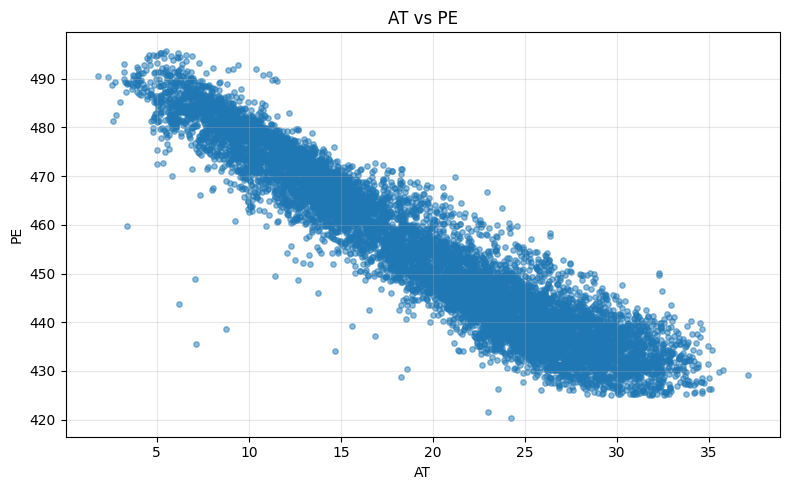

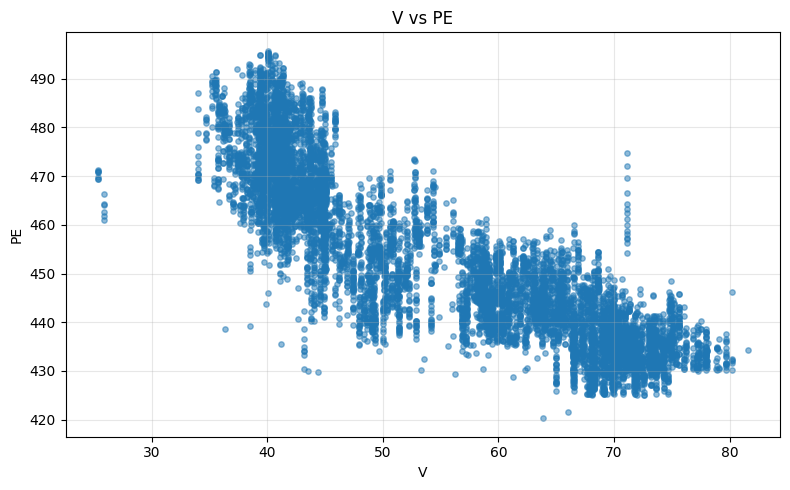

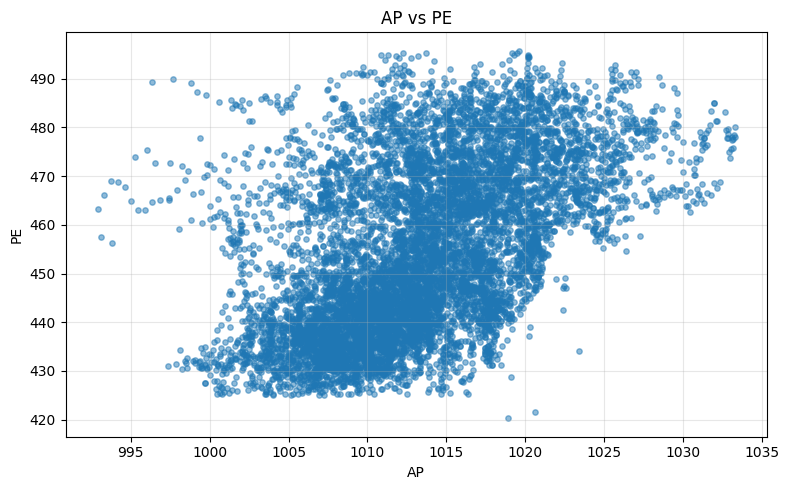

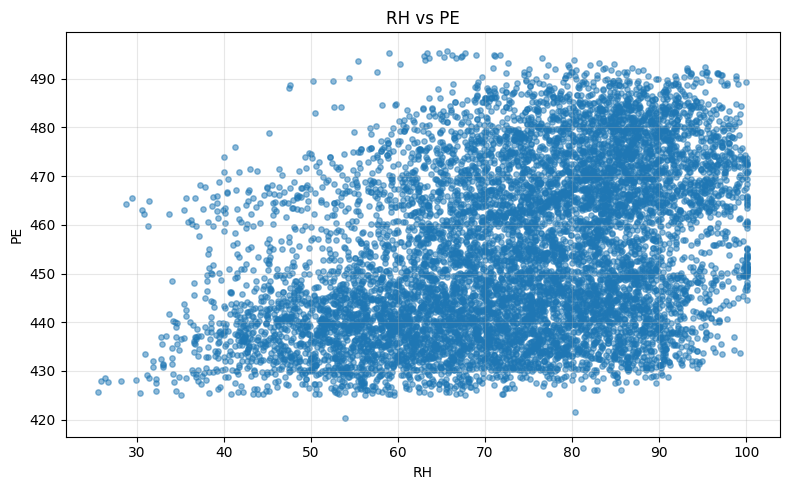

In [6]:
plot_features_against_target(
    X_all,
    y_all,
    feature_names,
    target_name
)


In [7]:
# ============================================
# 4. TRAIN-VALIDATION SPLIT
# ============================================

def train_validation_split(X, y, validation_ratio=0.20, seed=42):
    """
    Randomly split data into training and validation sets.
    """

    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    rng = np.random.default_rng(seed)
    indices = rng.permutation(len(y))

    validation_size = int(len(y) * validation_ratio)

    validation_indices = indices[:validation_size]
    training_indices = indices[validation_size:]

    X_train = X[training_indices]
    y_train = y[training_indices]

    X_val = X[validation_indices]
    y_val = y[validation_indices]

    return X_train, X_val, y_train, y_val


In [8]:
X_train_raw, X_val_raw, y_train, y_val = train_validation_split(
    X_all,
    y_all,
    validation_ratio=0.20,
    seed=42
)

print("Training samples:", len(y_train))
print("Validation samples:", len(y_val))


Training samples: 7655
Validation samples: 1913


In [9]:
# ============================================
# 5. FEATURE SCALING + DUMMY FEATURE
# ============================================

def process_multivariable_data(
    X_train,
    X_val=None,
    feature_scaling=False
):
    """
    Prepare multivariable data for linear regression.

    IMPORTANT:
        Scaling parameters are learned ONLY from training data,
        then the same mean/std are applied to validation data.

    Returns:
        X_train_processed
        X_val_processed
        scale_params
    """

    X_train = np.asarray(X_train, dtype=float)

    scale_params = {
        "scaled": feature_scaling,
        "mean": np.zeros(X_train.shape[1]),
        "std": np.ones(X_train.shape[1])
    }

    X_train_processed = X_train.copy()

    if X_val is not None:
        X_val = np.asarray(X_val, dtype=float)
        X_val_processed = X_val.copy()
    else:
        X_val_processed = None

    # ----------------------------------------
    # Feature scaling
    # ----------------------------------------

    if feature_scaling:

        mean = np.mean(X_train, axis=0)
        std = np.std(X_train, axis=0)

        # Safety against division by zero
        std[std == 0] = 1.0

        X_train_processed = (X_train - mean) / std

        if X_val is not None:
            X_val_processed = (X_val - mean) / std

        scale_params["mean"] = mean
        scale_params["std"] = std

    # ----------------------------------------
    # Add dummy feature x0 = 1
    # ----------------------------------------

    X_train_processed = np.column_stack((
        np.ones(len(X_train_processed)),
        X_train_processed
    ))

    if X_val_processed is not None:
        X_val_processed = np.column_stack((
            np.ones(len(X_val_processed)),
            X_val_processed
        ))

    return X_train_processed, X_val_processed, scale_params


In [10]:
# ============================================
# 6. COMPUTE COST
# ============================================

def compute_cost(X, y, theta):
    """
    Compute the mean squared error cost:

        J(theta) = 1/(2m) * sum((Xtheta - y)^2)
    """

    m = len(y)

    predictions = X.dot(theta)
    errors = predictions - y

    cost = (1 / (2 * m)) * np.sum(errors ** 2)

    return cost


In [11]:
# ============================================
# 7. GRADIENT DESCENT
# ============================================

def gradient_descent(
    X_train,
    y_train,
    theta,
    learning_rate,
    iterations,
    X_val=None,
    y_val=None
):
    """
    Perform batch gradient descent.

    Stores both training and validation cost
    after every iteration.
    """

    m = len(y_train)

    train_cost_history = []
    val_cost_history = []

    best_theta = theta.copy()
    best_val_cost = np.inf
    best_iteration = -1

    for i in range(iterations):

        # ------------------------------------
        # 1. Calculate predictions
        # ------------------------------------
        predictions = X_train.dot(theta)

        # ------------------------------------
        # 2. Calculate errors
        # ------------------------------------
        errors = predictions - y_train

        # ------------------------------------
        # 3. Calculate gradient
        # ------------------------------------
        gradient = (1 / m) * X_train.T.dot(errors)

        # ------------------------------------
        # 4. Update theta
        # ------------------------------------
        theta = theta - learning_rate * gradient

        # ------------------------------------
        # 5. Calculate training cost
        # ------------------------------------
        train_cost = compute_cost(X_train, y_train, theta)
        train_cost_history.append(train_cost)

        # ------------------------------------
        # 6. Calculate validation cost
        # ------------------------------------
        if X_val is not None and y_val is not None:

            val_cost = compute_cost(X_val, y_val, theta)
            val_cost_history.append(val_cost)

            if val_cost < best_val_cost:
                best_val_cost = val_cost
                best_theta = theta.copy()
                best_iteration = i + 1

    # If no validation set is supplied, use final theta
    if X_val is None or y_val is None:
        best_theta = theta.copy()
        best_val_cost = None
        best_iteration = iterations

    return (
        theta,
        train_cost_history,
        val_cost_history,
        best_theta,
        best_val_cost,
        best_iteration
    )


In [12]:
# ============================================
# 8. TRAIN
# ============================================

def train(
    X_train,
    y_train,
    X_val=None,
    y_val=None,
    learning_rate=0.01,
    iterations=1000
):
    """
    Train linear regression using batch gradient descent.
    """

    n = X_train.shape[1]

    # Initialize theta with zeros
    theta = np.zeros(n)

    return gradient_descent(
        X_train,
        y_train,
        theta,
        learning_rate,
        iterations,
        X_val,
        y_val
    )


In [13]:
# ============================================
# 9. PLOT TRAINING + VALIDATION ERROR
# ============================================

def plot_error_curves(
    train_cost_history,
    val_cost_history,
    title="Training and Validation Error"
):
    """
    Plot training and validation error against iterations.
    """

    plt.figure(figsize=(8, 5))

    iterations = range(1, len(train_cost_history) + 1)

    plt.plot(
        iterations,
        train_cost_history,
        label="Training Error"
    )

    if len(val_cost_history) > 0:
        plt.plot(
            iterations,
            val_cost_history,
            label="Validation Error"
        )

    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.title(title)

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [14]:
# ============================================
# 10. CONVERT PARAMETERS TO ORIGINAL SCALE
# ============================================

def original_scale_parameters(theta, scale_params):
    """
    Convert parameters learned on standardized features
    back to the original feature scale.

    If:
        z_j = (x_j - mean_j) / std_j

    then:
        y = theta_0 + sum(theta_j * z_j)

    becomes:
        y = beta_0 + sum(beta_j * x_j)
    """

    if not scale_params["scaled"]:
        return theta.copy()

    mean = scale_params["mean"]
    std = scale_params["std"]

    beta = np.zeros_like(theta)

    beta[1:] = theta[1:] / std
    beta[0] = theta[0] - np.sum(theta[1:] * mean / std)

    return beta


In [15]:
# ============================================
# 11. PRINT MULTIVARIABLE PARAMETERS
# ============================================

def print_multivariable_parameters(theta, feature_names, scale_params):
    """
    Print learned parameters in both processed
    and original feature scales.
    """

    print("=" * 60)
    print("LEARNED MODEL PARAMETERS")
    print("=" * 60)

    print(f"theta_0 = {theta[0]:.6f}")

    for j, name in enumerate(feature_names, start=1):
        print(f"theta_{j} ({name}) = {theta[j]:.6f}")

    beta = original_scale_parameters(theta, scale_params)

    print("\nOriginal feature scale:")
    print(f"Intercept = {beta[0]:.6f}")

    for j, name in enumerate(feature_names, start=1):
        print(f"Coefficient of {name} = {beta[j]:.6f}")

    print("\nOriginal-scale equation:")

    equation = f"PE_hat = {beta[0]:.6f}"

    for j, name in enumerate(feature_names, start=1):
        equation += f" + ({beta[j]:.6f})*{name}"

    print(equation)
    print("=" * 60)


In [16]:
# ============================================
# PART A - WITHOUT FEATURE SCALING
# ============================================

X_train_no_scale, X_val_no_scale, params_no_scale = process_multivariable_data(
    X_train_raw,
    X_val_raw,
    feature_scaling=False
)

# Raw features have very different magnitudes.
# Therefore a very small learning rate is required.
raw_learning_rate = 0.0000005
raw_iterations = 5000

(
    theta_raw_final,
    train_cost_raw,
    val_cost_raw,
    theta_raw_best,
    best_val_raw,
    best_iter_raw
) = train(
    X_train_no_scale,
    y_train,
    X_val_no_scale,
    y_val,
    learning_rate=raw_learning_rate,
    iterations=raw_iterations
)

best_train_raw = compute_cost(
    X_train_no_scale,
    y_train,
    theta_raw_best
)

print("Training completed WITHOUT feature scaling.")
print(f"Learning rate = {raw_learning_rate}")
print(f"Best iteration = {best_iter_raw}")
print(f"Training cost at best iteration = {best_train_raw:.6f}")
print(f"Best validation cost = {best_val_raw:.6f}")

print_multivariable_parameters(
    theta_raw_best,
    feature_names,
    params_no_scale
)


Training completed WITHOUT feature scaling.
Learning rate = 5e-07
Best iteration = 5000
Training cost at best iteration = 54.835725
Best validation cost = 54.837414
LEARNED MODEL PARAMETERS
theta_0 = 0.000381
theta_1 (AT) = -0.205242
theta_2 (V) = -0.313458
theta_3 (AP) = 0.457404
theta_4 (RH) = 0.162300

Original feature scale:
Intercept = 0.000381
Coefficient of AT = -0.205242
Coefficient of V = -0.313458
Coefficient of AP = 0.457404
Coefficient of RH = 0.162300

Original-scale equation:
PE_hat = 0.000381 + (-0.205242)*AT + (-0.313458)*V + (0.457404)*AP + (0.162300)*RH


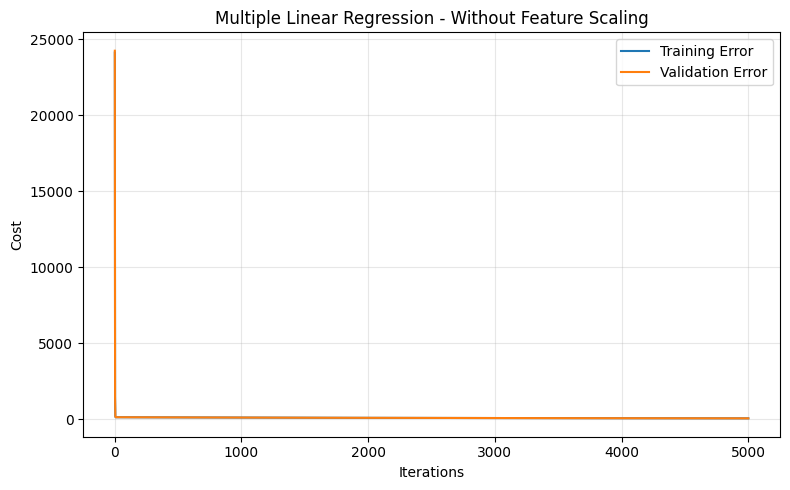

In [17]:
plot_error_curves(
    train_cost_raw,
    val_cost_raw,
    title="Multiple Linear Regression - Without Feature Scaling"
)


In [18]:
# ============================================
# PART A - WITH FEATURE SCALING
# ============================================

X_train_scaled, X_val_scaled, params_scaled = process_multivariable_data(
    X_train_raw,
    X_val_raw,
    feature_scaling=True
)

scaled_learning_rate = 0.05
scaled_iterations = 1000

(
    theta_scaled_final,
    train_cost_scaled,
    val_cost_scaled,
    theta_scaled_best,
    best_val_scaled,
    best_iter_scaled
) = train(
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
    learning_rate=scaled_learning_rate,
    iterations=scaled_iterations
)

best_train_scaled = compute_cost(
    X_train_scaled,
    y_train,
    theta_scaled_best
)

print("Training completed WITH feature scaling.")
print(f"Learning rate = {scaled_learning_rate}")
print(f"Best iteration = {best_iter_scaled}")
print(f"Training cost at best iteration = {best_train_scaled:.6f}")
print(f"Best validation cost = {best_val_scaled:.6f}")

print_multivariable_parameters(
    theta_scaled_best,
    feature_names,
    params_scaled
)


Training completed WITH feature scaling.
Learning rate = 0.05
Best iteration = 1000
Training cost at best iteration = 10.482488
Best validation cost = 10.007414
LEARNED MODEL PARAMETERS
theta_0 = 454.248138
theta_1 (AT) = -14.543817
theta_2 (V) = -3.114429
theta_3 (AP) = 0.428379
theta_4 (RH) = -2.263662

Original feature scale:
Intercept = 443.666362
Coefficient of AT = -1.951346
Coefficient of V = -0.245150
Coefficient of AP = 0.072762
Coefficient of RH = -0.154903

Original-scale equation:
PE_hat = 443.666362 + (-1.951346)*AT + (-0.245150)*V + (0.072762)*AP + (-0.154903)*RH


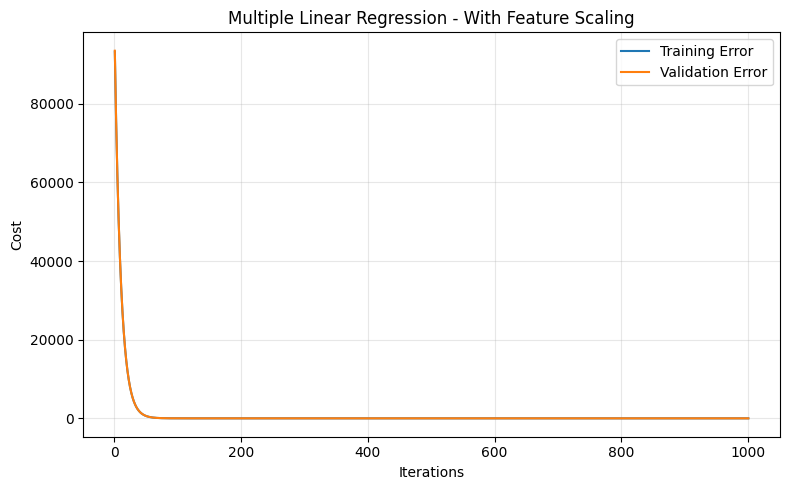

In [19]:
plot_error_curves(
    train_cost_scaled,
    val_cost_scaled,
    title="Multiple Linear Regression - With Feature Scaling"
)


In [20]:
# ============================================
# PART A - COMPARE BEFORE/AFTER SCALING
# ============================================

comparison = pd.DataFrame({
    "Setting": [
        "Without Feature Scaling",
        "With Feature Scaling"
    ],
    "Learning Rate": [
        raw_learning_rate,
        scaled_learning_rate
    ],
    "Iterations": [
        raw_iterations,
        scaled_iterations
    ],
    "Best Training Cost": [
        best_train_raw,
        best_train_scaled
    ],
    "Best Validation Cost": [
        best_val_raw,
        best_val_scaled
    ],
    "Best Iteration": [
        best_iter_raw,
        best_iter_scaled
    ]
})

print(comparison.to_string(index=False))

print("\nObservation:")
print(
    "Feature scaling allows a much larger learning rate and "
    "usually reaches the minimum validation error much faster."
)


                Setting  Learning Rate  Iterations  Best Training Cost  Best Validation Cost  Best Iteration
Without Feature Scaling   5.000000e-07        5000           54.835725             54.837414            5000
   With Feature Scaling   5.000000e-02        1000           10.482488             10.007414            1000

Observation:
Feature scaling allows a much larger learning rate and usually reaches the minimum validation error much faster.


In [21]:
# ============================================
# 12. CREATE K FOLDS
# ============================================

def create_k_folds(n_samples, k=5, seed=42):
    """
    Return k arrays of validation indices.
    Each sample appears in exactly one validation fold.
    """

    rng = np.random.default_rng(seed)
    indices = rng.permutation(n_samples)

    folds = np.array_split(indices, k)

    return folds


In [22]:
# ============================================
# 13. K-FOLD CROSS VALIDATION
# ============================================

def k_fold_cross_validation(
    X,
    y,
    feature_names,
    k=5,
    learning_rate=0.05,
    iterations=1000,
    seed=42
):
    """
    Perform manual k-fold cross validation.

    For every fold:
        1. Use one fold as validation data.
        2. Use remaining folds as training data.
        3. Fit scaling only on that training fold.
        4. Train with gradient descent.
        5. Save best validation parameters and errors.
    """

    folds = create_k_folds(len(y), k=k, seed=seed)

    results = []
    original_thetas = []

    all_indices = np.arange(len(y))

    for fold_number in range(k):

        validation_indices = folds[fold_number]

        training_indices = np.setdiff1d(
            all_indices,
            validation_indices
        )

        X_train_fold_raw = X[training_indices]
        y_train_fold = y[training_indices]

        X_val_fold_raw = X[validation_indices]
        y_val_fold = y[validation_indices]

        # Scale using ONLY the current training fold
        (
            X_train_fold,
            X_val_fold,
            scale_params_fold
        ) = process_multivariable_data(
            X_train_fold_raw,
            X_val_fold_raw,
            feature_scaling=True
        )

        (
            theta_final,
            train_history,
            val_history,
            theta_best,
            best_val_cost,
            best_iteration
        ) = train(
            X_train_fold,
            y_train_fold,
            X_val_fold,
            y_val_fold,
            learning_rate=learning_rate,
            iterations=iterations
        )

        training_cost = compute_cost(
            X_train_fold,
            y_train_fold,
            theta_best
        )

        theta_original = original_scale_parameters(
            theta_best,
            scale_params_fold
        )

        original_thetas.append(theta_original)

        fold_result = {
            "Fold": fold_number + 1,
            "Training Cost": training_cost,
            "Validation Cost": best_val_cost,
            "Best Iteration": best_iteration
        }

        for j, name in enumerate(["Intercept"] + feature_names):
            fold_result[name] = theta_original[j]

        results.append(fold_result)

    results_df = pd.DataFrame(results)
    average_theta = np.mean(np.vstack(original_thetas), axis=0)

    return results_df, average_theta


In [23]:
# ============================================
# PART B - 5-FOLD CROSS VALIDATION
# ============================================

cv_results, cv_average_theta = k_fold_cross_validation(
    X_all,
    y_all,
    feature_names,
    k=5,
    learning_rate=0.05,
    iterations=1000,
    seed=42
)

print("5-Fold Cross Validation Results:\n")
print(cv_results.to_string(index=False))

print("\nAverage validation cost:")
print(f"{cv_results['Validation Cost'].mean():.6f}")

print("\nAverage original-scale parameters:")
print(f"Intercept = {cv_average_theta[0]:.6f}")

for j, name in enumerate(feature_names, start=1):
    print(f"Coefficient of {name} = {cv_average_theta[j]:.6f}")


5-Fold Cross Validation Results:

 Fold  Training Cost  Validation Cost  Best Iteration  Intercept        AT         V       AP        RH
    1      10.479128        10.021004            1000 443.985972 -1.951410 -0.245258 0.072454 -0.154886
    2      10.215962        11.056107            1000 453.795890 -1.972757 -0.237036 0.062852 -0.156579
    3      10.398431        10.347807             652 443.735836 -1.946766 -0.245752 0.072563 -0.153938
    4      10.446233        10.161858             646 451.145280 -1.947370 -0.249491 0.065392 -0.153501
    5      10.390025        10.370240             754 452.678507 -1.958716 -0.239986 0.063592 -0.152983

Average validation cost:
10.391403

Average original-scale parameters:
Intercept = 449.068297
Coefficient of AT = -1.955404
Coefficient of V = -0.243505
Coefficient of AP = 0.067370
Coefficient of RH = -0.154377


In [24]:
# ============================================
# PART B - COMPARE PARAMETERS
# ============================================

single_split_theta = original_scale_parameters(
    theta_scaled_best,
    params_scaled
)

parameter_comparison = pd.DataFrame({
    "Parameter": ["Intercept"] + feature_names,
    "Single Train/Validation Split": single_split_theta,
    "5-Fold CV Average": cv_average_theta,
    "Absolute Difference": np.abs(
        single_split_theta - cv_average_theta
    )
})

print(parameter_comparison.to_string(index=False))

print("\nObservation:")
print(
    "The 5-fold values are averages across multiple train/validation "
    "partitions, so they are less dependent on one particular split."
)


Parameter  Single Train/Validation Split  5-Fold CV Average  Absolute Difference
Intercept                     443.666362         449.068297             5.401935
       AT                      -1.951346          -1.955404             0.004058
        V                      -0.245150          -0.243505             0.001645
       AP                       0.072762           0.067370             0.005392
       RH                      -0.154903          -0.154377             0.000525

Observation:
The 5-fold values are averages across multiple train/validation partitions, so they are less dependent on one particular split.


In [25]:
# ============================================
# 14. LOAD POLYNOMIAL-REGRESSION DATA
# ============================================

def load_polynomial_data(filename):
    """
    Load data_02b.csv containing columns x and y.
    """

    data = pd.read_csv(filename)

    x = data["x"].values.astype(float)
    y = data["y"].values.astype(float)

    return x, y, data


In [26]:
# Upload data_02b.csv to the notebook working directory before running.

x_poly_all, y_poly_all, poly_data = load_polynomial_data(
    "data_02b.csv"
)

print("Polynomial-regression dataset loaded.")
print("Number of samples:", len(y_poly_all))

print("\nFirst 5 rows:")
print(poly_data.head())


Polynomial-regression dataset loaded.
Number of samples: 9568

First 5 rows:
       x       y
0  14.96  463.26
1  25.18  444.37
2   5.11  488.56
3  20.86  446.48
4  10.82  473.90


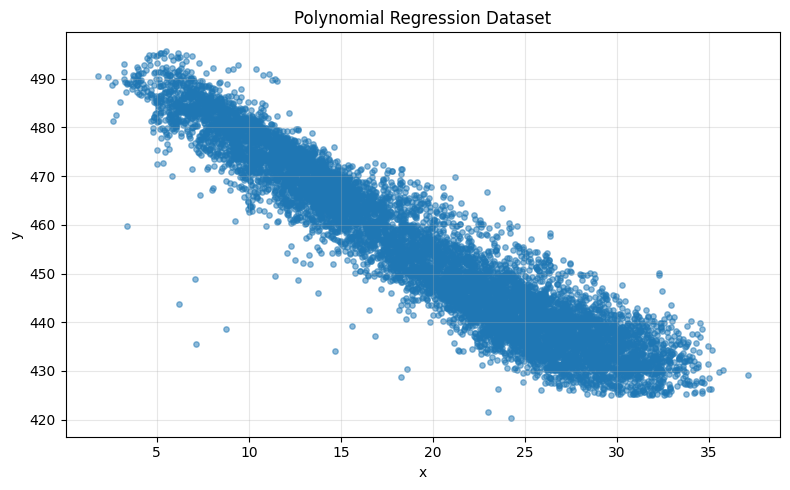

In [27]:
# ============================================
# 15. PLOT POLYNOMIAL DATA
# ============================================

plt.figure(figsize=(8, 5))

plt.scatter(
    x_poly_all,
    y_poly_all,
    s=15,
    alpha=0.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial Regression Dataset")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [28]:
# ============================================
# 16. POLYNOMIAL FEATURE PROCESSING
# ============================================

def process_polynomial_data(
    x_train,
    degree,
    x_val=None,
    scale_params=None
):
    """
    Standardize x and create polynomial features:

        degree 1: [1, z]
        degree 2: [1, z, z^2]
        degree 3: [1, z, z^2, z^3]

    where:
        z = (x - mean) / std
    """

    x_train = np.asarray(x_train, dtype=float)

    if scale_params is None:
        mean = np.mean(x_train)
        std = np.std(x_train)

        if std == 0:
            std = 1.0

        scale_params = {
            "mean": mean,
            "std": std
        }
    else:
        mean = scale_params["mean"]
        std = scale_params["std"]

    z_train = (x_train - mean) / std

    X_train = np.column_stack([
        z_train ** power
        for power in range(degree + 1)
    ])

    X_val = None

    if x_val is not None:
        x_val = np.asarray(x_val, dtype=float)
        z_val = (x_val - mean) / std

        X_val = np.column_stack([
            z_val ** power
            for power in range(degree + 1)
        ])

    return X_train, X_val, scale_params


In [29]:
# ============================================
# 17. CONVERT POLYNOMIAL PARAMETERS
#     BACK TO ORIGINAL x SCALE
# ============================================

def polynomial_original_coefficients(theta, scale_params):
    """
    Convert coefficients from powers of standardized z
    to powers of the original x.

    Returns coefficients [a0, a1, a2, ...] such that:

        y_hat = a0 + a1*x + a2*x^2 + ...
    """

    mean = scale_params["mean"]
    std = scale_params["std"]

    # z = -mean/std + (1/std)x
    z_polynomial = np.polynomial.Polynomial([
        -mean / std,
        1 / std
    ])

    original_polynomial = np.polynomial.Polynomial([0.0])

    for power, coefficient in enumerate(theta):
        original_polynomial = (
            original_polynomial
            + coefficient * (z_polynomial ** power)
        )

    return original_polynomial.coef


In [30]:
# ============================================
# PART C - TRAIN/VALIDATION SPLIT
# ============================================

x_poly_train, x_poly_val, y_poly_train, y_poly_val = train_validation_split(
    x_poly_all.reshape(-1, 1),
    y_poly_all,
    validation_ratio=0.20,
    seed=42
)

# Convert back from (m,1) to (m,)
x_poly_train = x_poly_train.ravel()
x_poly_val = x_poly_val.ravel()

print("Training samples:", len(y_poly_train))
print("Validation samples:", len(y_poly_val))


Training samples: 7655
Validation samples: 1913


In [31]:
# ============================================
# PART C - TRAIN d = 1, 2, 3
# ============================================

polynomial_results = {}

degrees = [1, 2, 3]

for degree in degrees:

    X_poly_train, X_poly_val, poly_scale = process_polynomial_data(
        x_poly_train,
        degree,
        x_val=x_poly_val
    )

    (
        theta_final,
        train_history,
        val_history,
        theta_best,
        best_val_cost,
        best_iteration
    ) = train(
        X_poly_train,
        y_poly_train,
        X_poly_val,
        y_poly_val,
        learning_rate=0.03,
        iterations=2000
    )

    best_train_cost = compute_cost(
        X_poly_train,
        y_poly_train,
        theta_best
    )

    original_coefficients = polynomial_original_coefficients(
        theta_best,
        poly_scale
    )

    polynomial_results[degree] = {
        "theta": theta_best,
        "scale_params": poly_scale,
        "train_history": train_history,
        "val_history": val_history,
        "training_cost": best_train_cost,
        "validation_cost": best_val_cost,
        "best_iteration": best_iteration,
        "original_coefficients": original_coefficients
    }

    print("=" * 55)
    print(f"Degree d = {degree}")
    print(f"Best iteration = {best_iteration}")
    print(f"Training cost = {best_train_cost:.6f}")
    print(f"Validation cost = {best_val_cost:.6f}")
    print("Theta (standardized x basis) =", theta_best)
    print("Original x coefficients =", original_coefficients)


Degree d = 1
Best iteration = 389
Training cost = 14.951499
Validation cost = 13.773533
Theta (standardized x basis) = [454.24489136 -16.16742552]
Original x coefficients = [496.9901382   -2.16918535]


Degree d = 2
Best iteration = 691
Training cost = 13.788425
Validation cost = 12.453008
Theta (standardized x basis) = [452.52403031 -15.91531308   1.66660966]
Original x coefficients = [ 5.06252765e+02 -3.31776545e+00  3.00016737e-02]


Degree d = 3
Best iteration = 696
Training cost = 13.085323
Validation cost = 11.840282
Theta (standardized x basis) = [452.45429734 -18.00881469   1.89850704   1.08378671]
Original x coefficients = [ 4.93308918e+02 -7.13771782e-01 -1.20571292e-01  2.61764776e-03]


In [32]:
# ============================================
# PART C - CHOOSE BEST DEGREE
# ============================================

best_degree = min(
    polynomial_results,
    key=lambda d: polynomial_results[d]["validation_cost"]
)

best_result = polynomial_results[best_degree]

print("Best polynomial degree:", best_degree)
print(f"Best validation cost: {best_result['validation_cost']:.6f}")
print(f"Training cost: {best_result['training_cost']:.6f}")

print("\nLearned parameters for best degree")
print("(standardized x basis):")

for j, value in enumerate(best_result["theta"]):
    print(f"theta_{j} = {value:.6f}")

print("\nEquivalent parameters on original x scale:")

for j, value in enumerate(best_result["original_coefficients"]):
    print(f"a_{j} = {value:.6f}")


Best polynomial degree: 3
Best validation cost: 11.840282
Training cost: 13.085323

Learned parameters for best degree
(standardized x basis):
theta_0 = 452.454297
theta_1 = -18.008815
theta_2 = 1.898507
theta_3 = 1.083787

Equivalent parameters on original x scale:
a_0 = 493.308918
a_1 = -0.713772
a_2 = -0.120571
a_3 = 0.002618


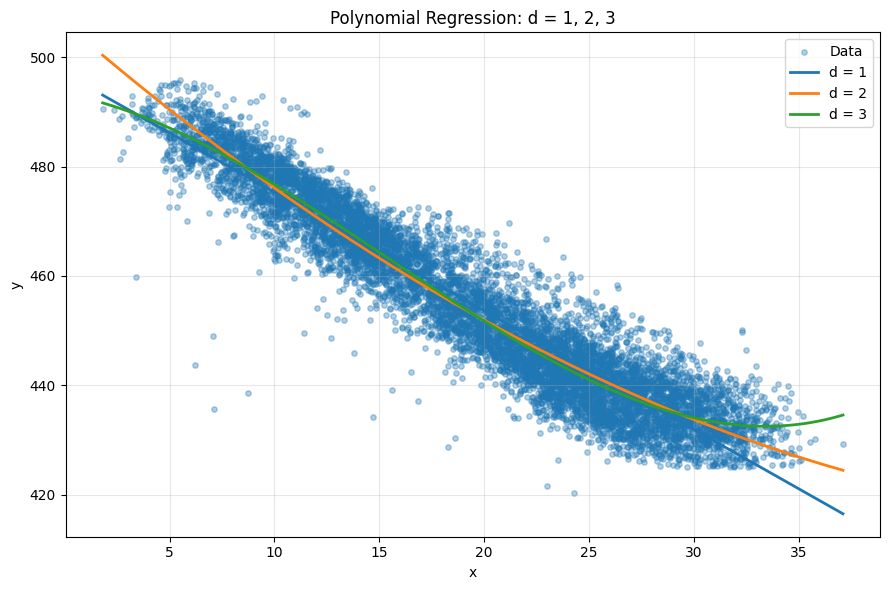

In [33]:
# ============================================
# PART C - PLOT ALL THREE FITTED CURVES
# ============================================

plt.figure(figsize=(9, 6))

plt.scatter(
    x_poly_all,
    y_poly_all,
    s=15,
    alpha=0.35,
    label="Data"
)

x_curve = np.linspace(
    x_poly_all.min(),
    x_poly_all.max(),
    500
)

for degree in degrees:

    result = polynomial_results[degree]

    _, X_curve, _ = process_polynomial_data(
        x_poly_train,
        degree,
        x_val=x_curve,
        scale_params=result["scale_params"]
    )

    y_curve = X_curve.dot(result["theta"])

    plt.plot(
        x_curve,
        y_curve,
        linewidth=2,
        label=f"d = {degree}"
    )

plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial Regression: d = 1, 2, 3")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


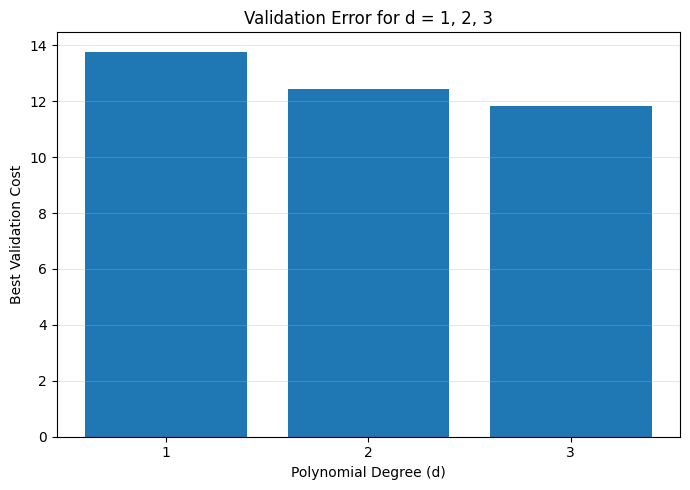

In [34]:
# ============================================
# PART C - BAR PLOT OF VALIDATION ERRORS
# ============================================

validation_errors = [
    polynomial_results[d]["validation_cost"]
    for d in degrees
]

plt.figure(figsize=(7, 5))

plt.bar(
    [str(d) for d in degrees],
    validation_errors
)

plt.xlabel("Polynomial Degree (d)")
plt.ylabel("Best Validation Cost")
plt.title("Validation Error for d = 1, 2, 3")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


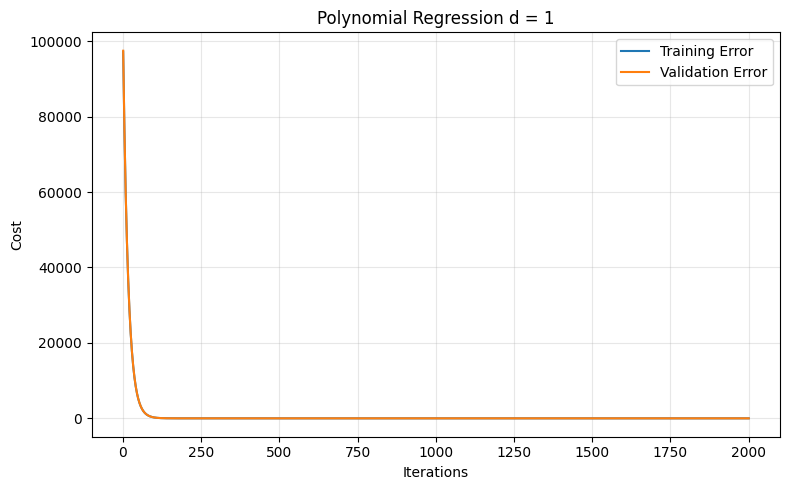

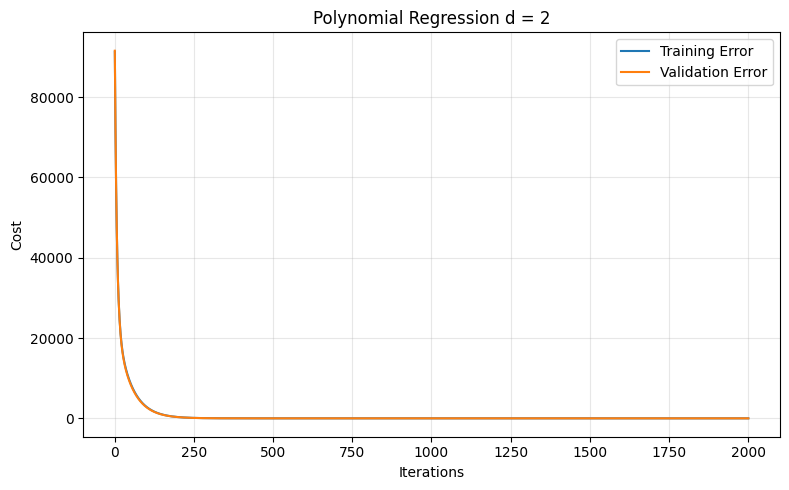

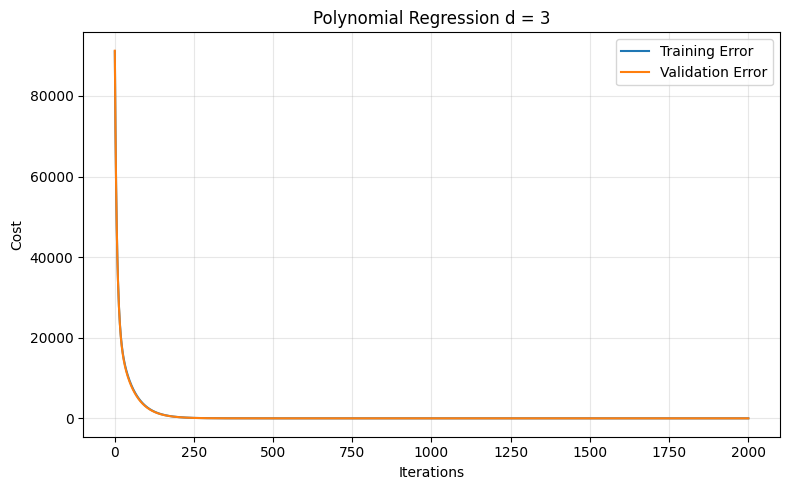

In [35]:
# ============================================
# PART C - TRAINING + VALIDATION ERROR CURVES
# ============================================

for degree in degrees:

    result = polynomial_results[degree]

    plot_error_curves(
        result["train_history"],
        result["val_history"],
        title=f"Polynomial Regression d = {degree}"
    )


In [36]:
# ============================================
# FINAL SUMMARY
# ============================================

print("=" * 70)
print("LAB 02 SUMMARY")
print("=" * 70)

print("\nPART A - Multiple Linear Regression")
print(f"Without scaling: best validation cost = {best_val_raw:.6f}")
print(f"With scaling   : best validation cost = {best_val_scaled:.6f}")
print(f"Scaled model best iteration = {best_iter_scaled}")

print("\nPART B - 5-Fold Cross Validation")
print(f"Average validation cost = {cv_results['Validation Cost'].mean():.6f}")
print("Average original-scale parameters:")
print(cv_average_theta)

print("\nPART C - Polynomial Regression")
print(f"Best degree = {best_degree}")
print(f"Best validation cost = {best_result['validation_cost']:.6f}")
print("Best original-scale coefficients:")
print(best_result["original_coefficients"])

print("=" * 70)


LAB 02 SUMMARY

PART A - Multiple Linear Regression
Without scaling: best validation cost = 54.837414
With scaling   : best validation cost = 10.007414
Scaled model best iteration = 1000

PART B - 5-Fold Cross Validation
Average validation cost = 10.391403
Average original-scale parameters:
[ 4.49068297e+02 -1.95540375e+00 -2.43504582e-01  6.73704889e-02
 -1.54377302e-01]

PART C - Polynomial Regression
Best degree = 3
Best validation cost = 11.840282
Best original-scale coefficients:
[ 4.93308918e+02 -7.13771782e-01 -1.20571292e-01  2.61764776e-03]
